<a href="https://colab.research.google.com/github/ldamaske/1IAST-Fase1/blob/main/Data_Science_Desafios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd # importacao da biblioteca para tratamento dos dados e criacao de dataframe formato colunar
import matplotlib.pyplot as plt

import numpy as np
import statistics as stats
import seaborn as sns


# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Carregar base
nps = pd.read_csv("/content/desafio_nps_fase_1.csv")


# Visual inicial
print(nps.head())
print(nps.info())

   customer_id  customer_age customer_region  customer_tenure_months  \
0            1            63        Nordeste                      14   
1            2            20             Sul                       1   
2            3            46        Nordeste                     111   
3            4            52    Centro-Oeste                     117   
4            5            56           Norte                      50   

   order_id  order_value  items_quantity  discount_value  \
0     50001       139.73               4           39.35   
1     50002       458.95               2            9.51   
2     50003       507.06               5           42.82   
3     50004       302.19               2           19.58   
4     50005       253.06               1           29.37   

   payment_installments  delivery_time_days  delivery_delay_days  \
0                     4                   2                    2   
1                    10                   6                    4   
2 

In [12]:
def categorizar_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

nps["nps_categoria"] = nps["nps_score"].apply(categorizar_nps)

# Distribuição
print(nps["nps_categoria"].value_counts())

nps_categoria
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64


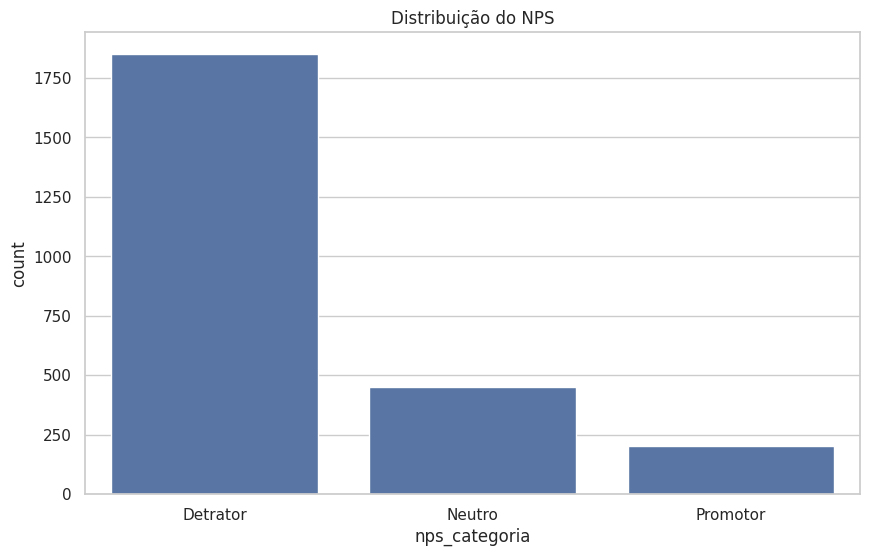

In [14]:
#como esta a distribuição do NPS ou seja a quantidade de amostra por grupo
sns.countplot(data=nps, x="nps_categoria", order=["Detrator", "Neutro", "Promotor"])
plt.title("Distribuição do NPS")
plt.show()

customer_region
Sul             4.490979
Nordeste        4.421649
Norte           4.382609
Sudeste         4.373846
Centro-Oeste    4.209829
Name: nps_score, dtype: float64


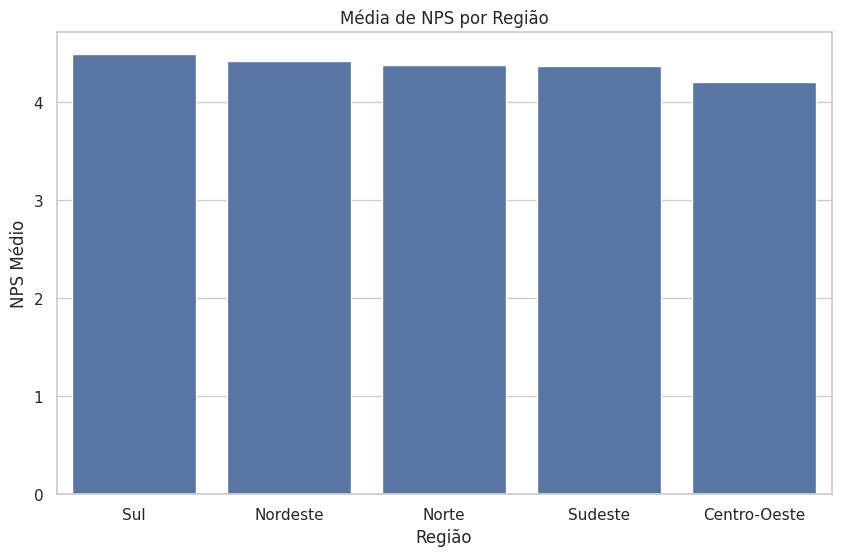

In [16]:
#NPS por região
nps_regiao = nps.groupby("customer_region")["nps_score"].mean().sort_values(ascending=False)

print(nps_regiao)

sns.barplot(x=nps_regiao.index, y=nps_regiao.values)
plt.title("Média de NPS por Região")
plt.ylabel("NPS Médio")
plt.xlabel("Região")
plt.show()


faixa_entrega
0-5      4.319534
5-10     4.488889
10-15    4.305815
15-20         NaN
Name: nps_score, dtype: float64


/tmp/ipykernel_20032/4238889811.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_entrega = nps.groupby("faixa_entrega")["nps_score"].mean()


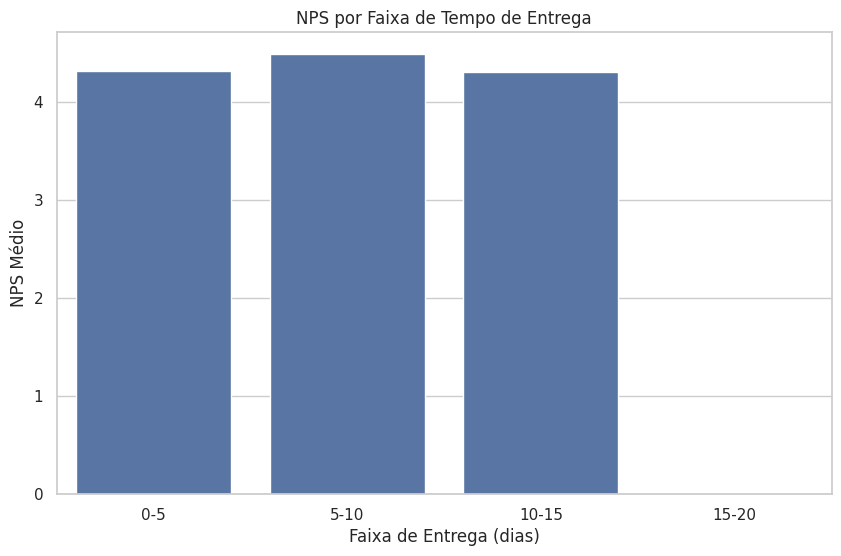

In [20]:
#NPS por tempo de entrega
# Criar faixas de entrega
nps["faixa_entrega"] = pd.cut(
    nps["delivery_time_days"],
    bins=[0,5,10,15,20],
    labels=["0-5", "5-10", "10-15", "15-20"]
)

nps_entrega = nps.groupby("faixa_entrega")["nps_score"].mean()

print(nps_entrega)

sns.barplot(x=nps_entrega.index, y=nps_entrega.values)
plt.title("NPS por Faixa de Tempo de Entrega")
plt.ylabel("NPS Médio")
plt.xlabel("Faixa de Entrega (dias)")
plt.show()


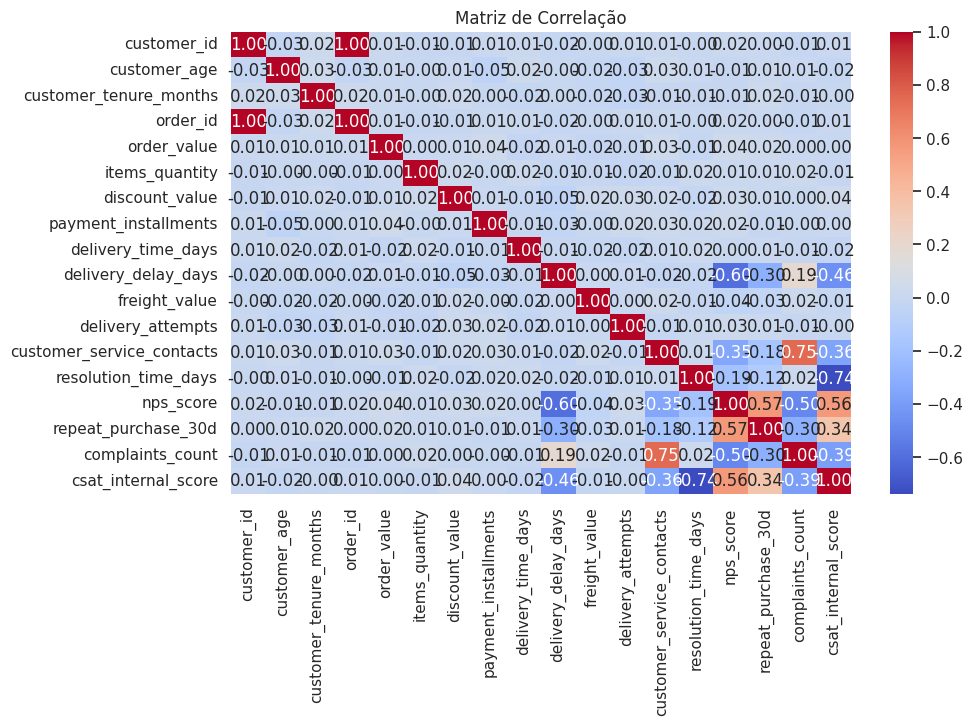

In [22]:
#correlacao geral numerica
corr = nps.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

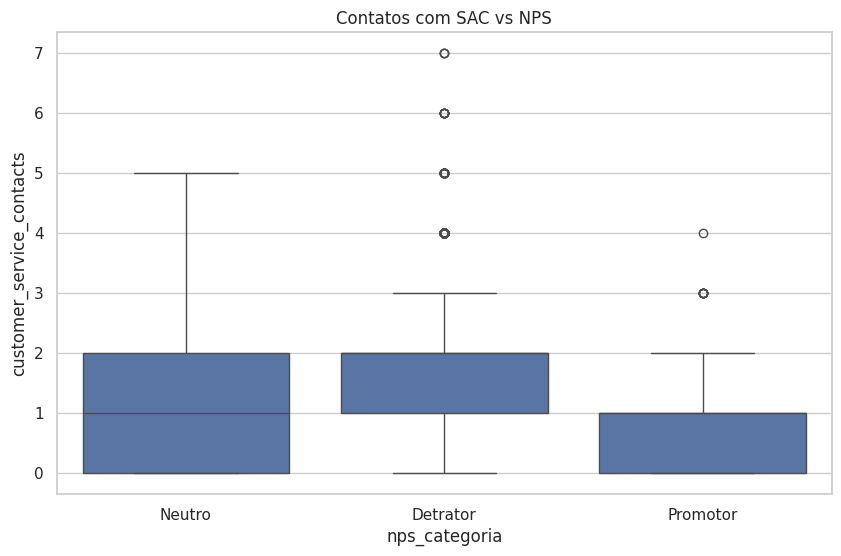

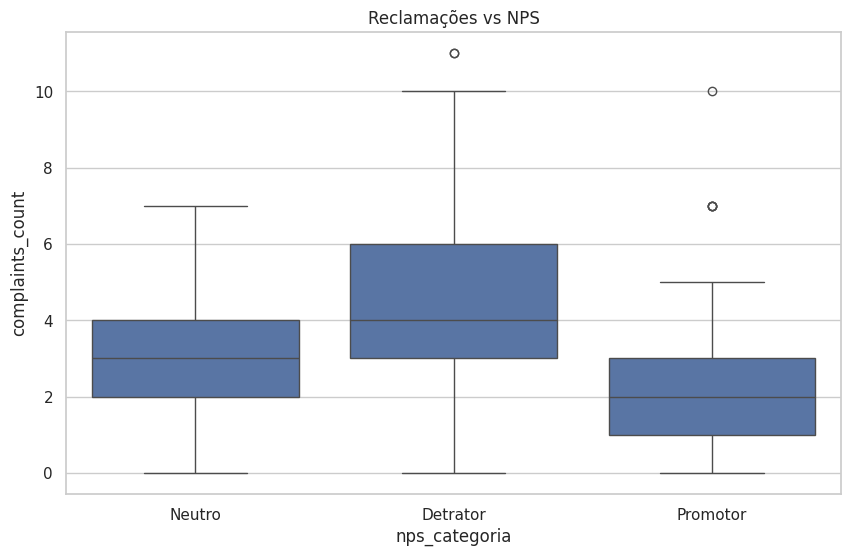

In [24]:
#Impacto no Atendimento
sns.boxplot(data=nps, x="nps_categoria", y="customer_service_contacts")
plt.title("Contatos com SAC vs NPS")
plt.show()

sns.boxplot(data=nps, x="nps_categoria", y="complaints_count")
plt.title("Reclamações vs NPS")
plt.show()


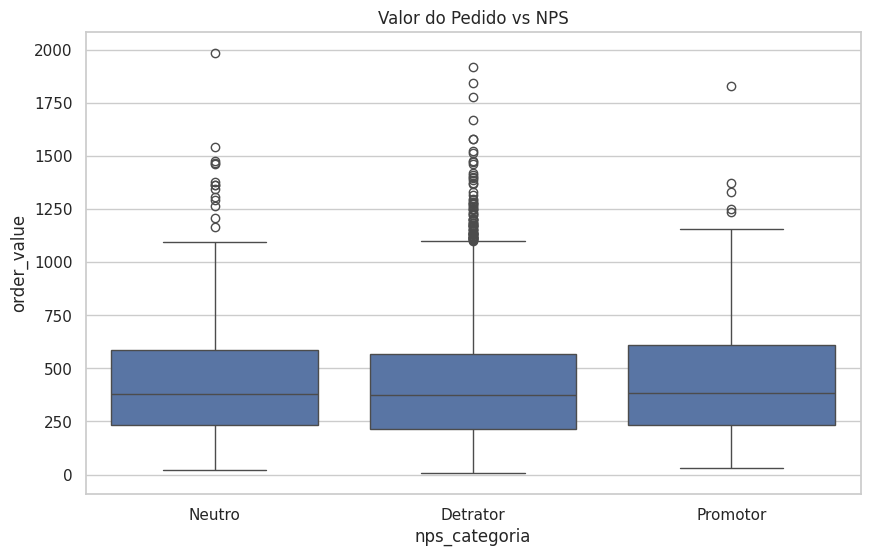

In [25]:
#Valor do pedido vs NPS
sns.boxplot(data=nps, x="nps_categoria", y="order_value")
plt.title("Valor do Pedido vs NPS")
plt.show()

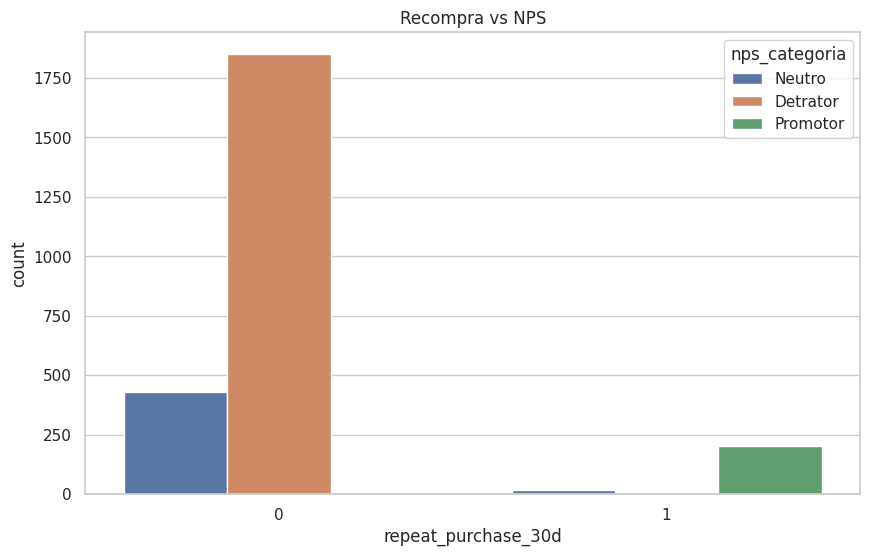

In [26]:
#Recompra vs NPS (verificar mais analises )
sns.countplot(data=nps, x="repeat_purchase_30d", hue="nps_categoria")
plt.title("Recompra vs NPS")
plt.show()


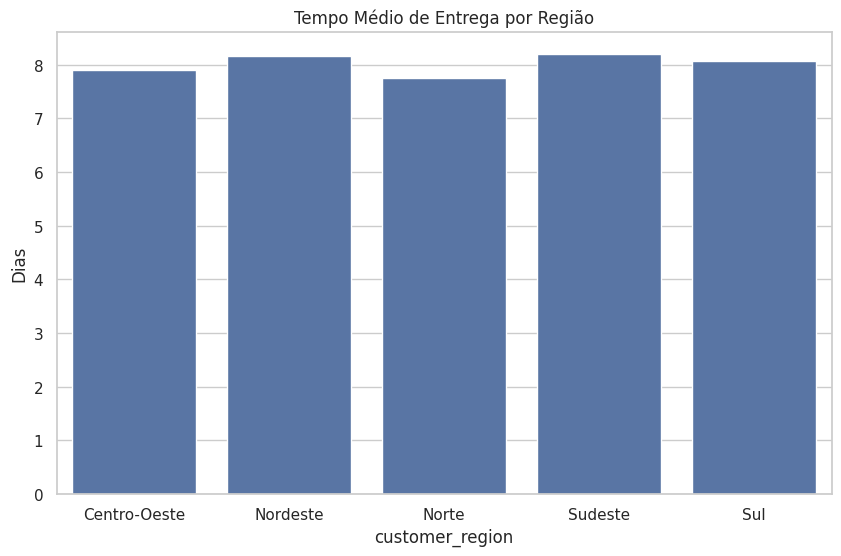

In [28]:
#Tempo medio por região
tempo_regiao = nps.groupby("customer_region")["delivery_time_days"].mean()

sns.barplot(x=tempo_regiao.index, y=tempo_regiao.values)
plt.title("Tempo Médio de Entrega por Região")
plt.ylabel("Dias")
plt.show()


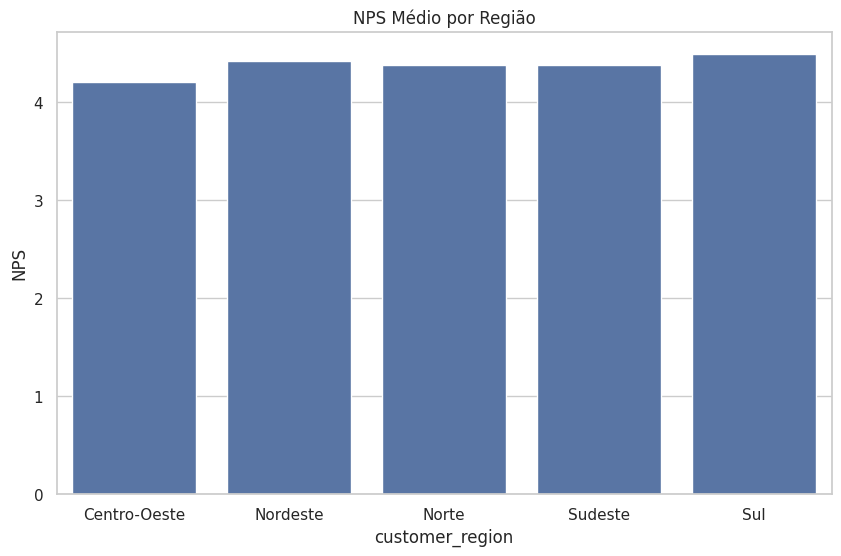

In [30]:
#NSP medio por regiao
nps_regiao = nps.groupby("customer_region")["nps_score"].mean()

sns.barplot(x=nps_regiao.index, y=nps_regiao.values)
plt.title("NPS Médio por Região")
plt.ylabel("NPS")
plt.show()

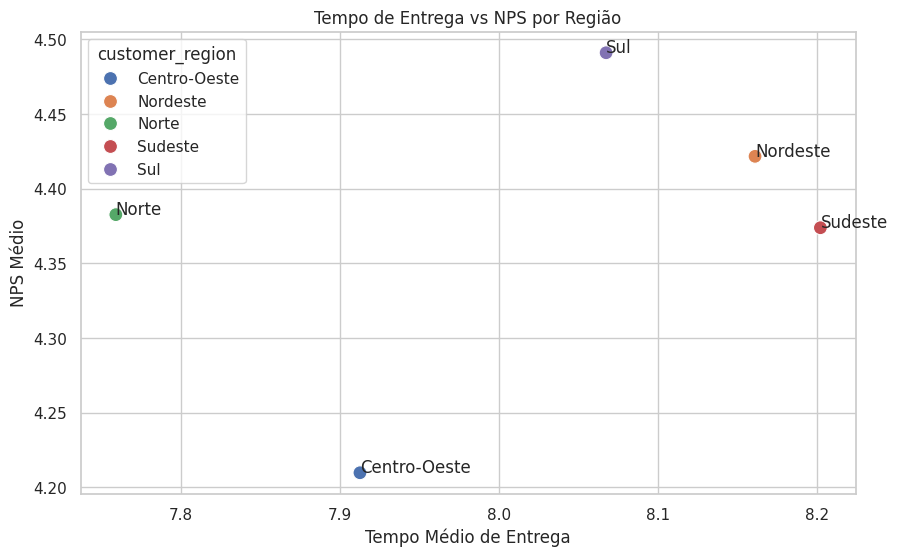

In [32]:
#Existe alguma correlação direta
agrupado = nps.groupby("customer_region").agg({
    "delivery_time_days": "mean",
    "nps_score": "mean"
}).reset_index()

sns.scatterplot(data=agrupado, x="delivery_time_days", y="nps_score", hue="customer_region", s=100)

for i in range(len(agrupado)):
    plt.text(
        agrupado["delivery_time_days"][i],
        agrupado["nps_score"][i],
        agrupado["customer_region"][i]
    )

plt.title("Tempo de Entrega vs NPS por Região")
plt.xlabel("Tempo Médio de Entrega")
plt.ylabel("NPS Médio")
plt.show()


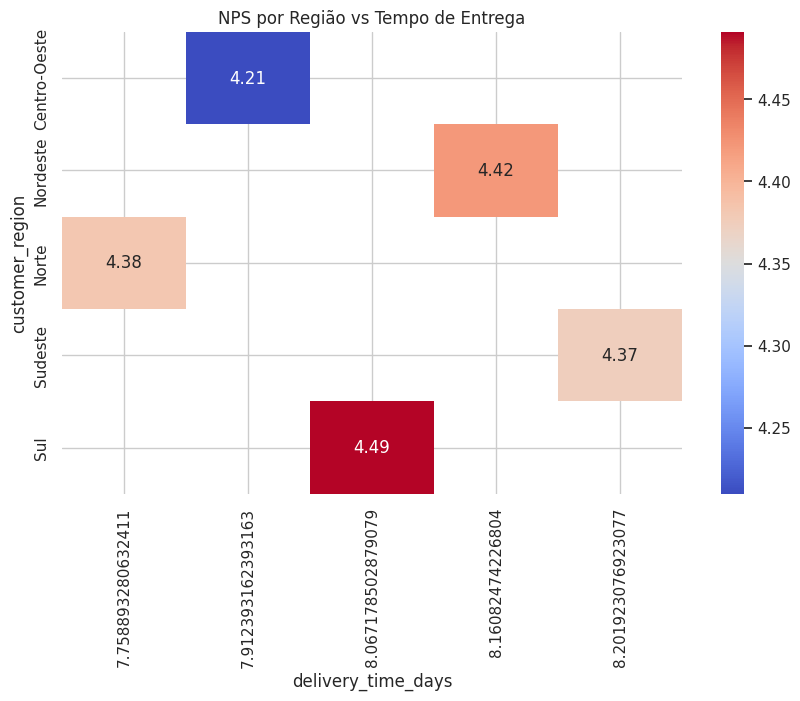

In [34]:
#
pivot = agrupado.pivot_table(
    values="nps_score",
    index="customer_region",
    columns="delivery_time_days",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("NPS por Região vs Tempo de Entrega")
plt.show()

In [ ]:
#

In [2]:
nps=pd.read_csv("/content/desafio_nps_fase_1.csv")
nps

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7


In [3]:
nps['nps_score'].describe()


,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


In [ ]:
nps['customer_region'].describe()

,customer_region
count,2500
unique,5
top,Sul
freq,521


In [ ]:
nps.groupby('customer_region')['nps_score'].mean().reset_index()

,customer_region,nps_score
0,Centro-Oeste,4.209829
1,Nordeste,4.421649
2,Norte,4.382609
3,Sudeste,4.373846
4,Sul,4.490979


In [6]:
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

nps['nps_categoria'] = nps['nps_score'].apply(classificar_nps)

In [ ]:
percentual = nps['nps_categoria'].value_counts(normalize=True) * 100

nps = percentual.get('Promotor', 0) - percentual.get('Detrator', 0)

print(f'NPS: {nps:.2f}')

NPS: -66.00


In [ ]:
import pandas as pd
nps = pd.read_csv("/content/desafio_nps_fase_1.csv")
corr = nps['csat_internal_score'].corr(nps['nps_score'])
print(f'Correlação CSAT vs NPS: {corr:.2f}')

Correlação CSAT vs NPS: 0.56


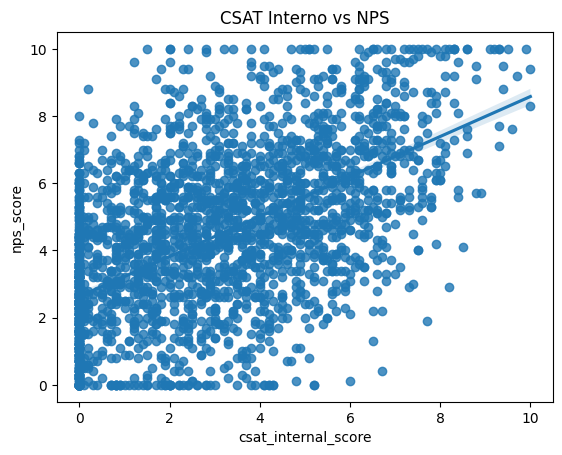

In [ ]:
#se existe uma correlação entre o nps que o cliente da nota com a nota interna tavelz do processo

sns.regplot(data=nps, x='csat_internal_score', y='nps_score')
plt.title('CSAT Interno vs NPS')
plt.show()

In [ ]:
#
X = nps[['delivery_delay_days', 'customer_age']]
y = nps['nps_score']

In [36]:
from sklearn.model_selection import train_test_split

# Definir as features (X)
# Assumindo que 'X' foi definido anteriormente na célula 3s6K9-WVTS2M como:
# X = nps[['delivery_delay_days', 'customer_age']]

# Definir a variável alvo (y_categorical)
# Assumindo que a função 'classificar_nps' foi definida na célula tGJRMJDYZEZF e 'nps' DataFrame está carregado.
# y_categorical = nps['nps_score'].apply(classificar_nps)

# Para garantir que X e y_categorical estão disponíveis, vou redefini-los aqui para clareza:
X = nps[['delivery_delay_days', 'customer_age']]
y_categorical = nps['nps_score'].apply(classificar_nps)

# Realizar a divisão dos dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print("Dados divididos em conjuntos de treino e teste com sucesso!")
print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

Dados divididos em conjuntos de treino e teste com sucesso!
Tamanho do conjunto de treino: 2000 amostras
Tamanho do conjunto de teste: 500 amostras


In [ ]:
#
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd #

# Definindo a funcao de categorizar o score_nps
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicando a classificação classificação a nps_score para criar um alvo categórico'
# O 'nps' contido no dataframe é
y_categorical = nps['nps_score'].apply(classificar_nps)

#Agora, use o y categórico para train_test_split
# Assume-se que X esteja definido a partir de uma célula anterior
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42) # Added random_state for reproducibility

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
accuracy = model.score(X_test, y_test)
print(f'Acurácia do modelo: {accuracy:.2f}')

Acurácia do modelo: 0.72


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Detrator       0.74      0.98      0.84       363
      Neutro       0.00      0.00      0.00        98
    Promotor       0.25      0.10      0.15        39

    accuracy                           0.72       500
   macro avg       0.33      0.36      0.33       500
weighted avg       0.55      0.72      0.62       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Impacto de cada variável em cada classe
#Ex: tempo alto aumenta chance de ser detrator
model.coef_

array([[ 0.71929059, -0.00258556],
       [-0.0034263 , -0.00168701],
       [-0.71586429,  0.00427257]])

In [ ]:
#Probabilidades
model.predict_proba(X_test)


array([[5.97121926e-01, 2.72359047e-01, 1.30519026e-01],
       [7.91227839e-01, 1.72378940e-01, 3.63932210e-02],
       [3.43784727e-01, 3.25064057e-01, 3.31151216e-01],
       ...,
       [9.47935417e-01, 4.93254402e-02, 2.73914282e-03],
       [7.75507945e-01, 1.75925729e-01, 4.85663255e-02],
       [9.73959827e-01, 2.52282901e-02, 8.11883292e-04]])

In [37]:
#avaliação de outro modelo abordagem verificar mais detalhes, dados talvez o modelo nao de a reposta para o negocios avaliar
#arvores de descisao
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Modelo (controlando profundidade para interpretabilidade)
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)

tree.fit(X_train, y_train)

# Previsão
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Detrator       0.74      0.97      0.84       363
      Neutro       0.00      0.00      0.00        98
    Promotor       0.27      0.18      0.22        39

    accuracy                           0.72       500
   macro avg       0.34      0.38      0.35       500
weighted avg       0.56      0.72      0.63       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
# Instalar a biblioteca imbalanced-learn, caso ainda não esteja instalada
%pip install imbalanced-learn

# Importar SMOTE
from imblearn.over_sampling import SMOTE

# Criar uma instância do SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE apenas aos dados de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição das classes após SMOTE:")
print(y_train_resampled.value_counts())

Distribuição das classes após SMOTE:
nps_score
Detrator    1488
Promotor    1488
Neutro      1488
Name: count, dtype: int64


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Treinar o modelo de Regressão Logística novamente com os dados reamostrados
model_resampled = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Fazer previsões no conjunto de teste (original, não reamostrado)
y_pred_resampled = model_resampled.predict(X_test)

# Avaliar o desempenho do modelo com os dados reamostrados
print("Relatório de Classificação após SMOTE:")
print(classification_report(y_test, y_pred_resampled))

Relatório de Classificação após SMOTE:
              precision    recall  f1-score   support

    Detrator       0.87      0.77      0.81       363
      Neutro       0.36      0.35      0.35        98
    Promotor       0.24      0.51      0.33        39

    accuracy                           0.67       500
   macro avg       0.49      0.54      0.50       500
weighted avg       0.72      0.67      0.69       500



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


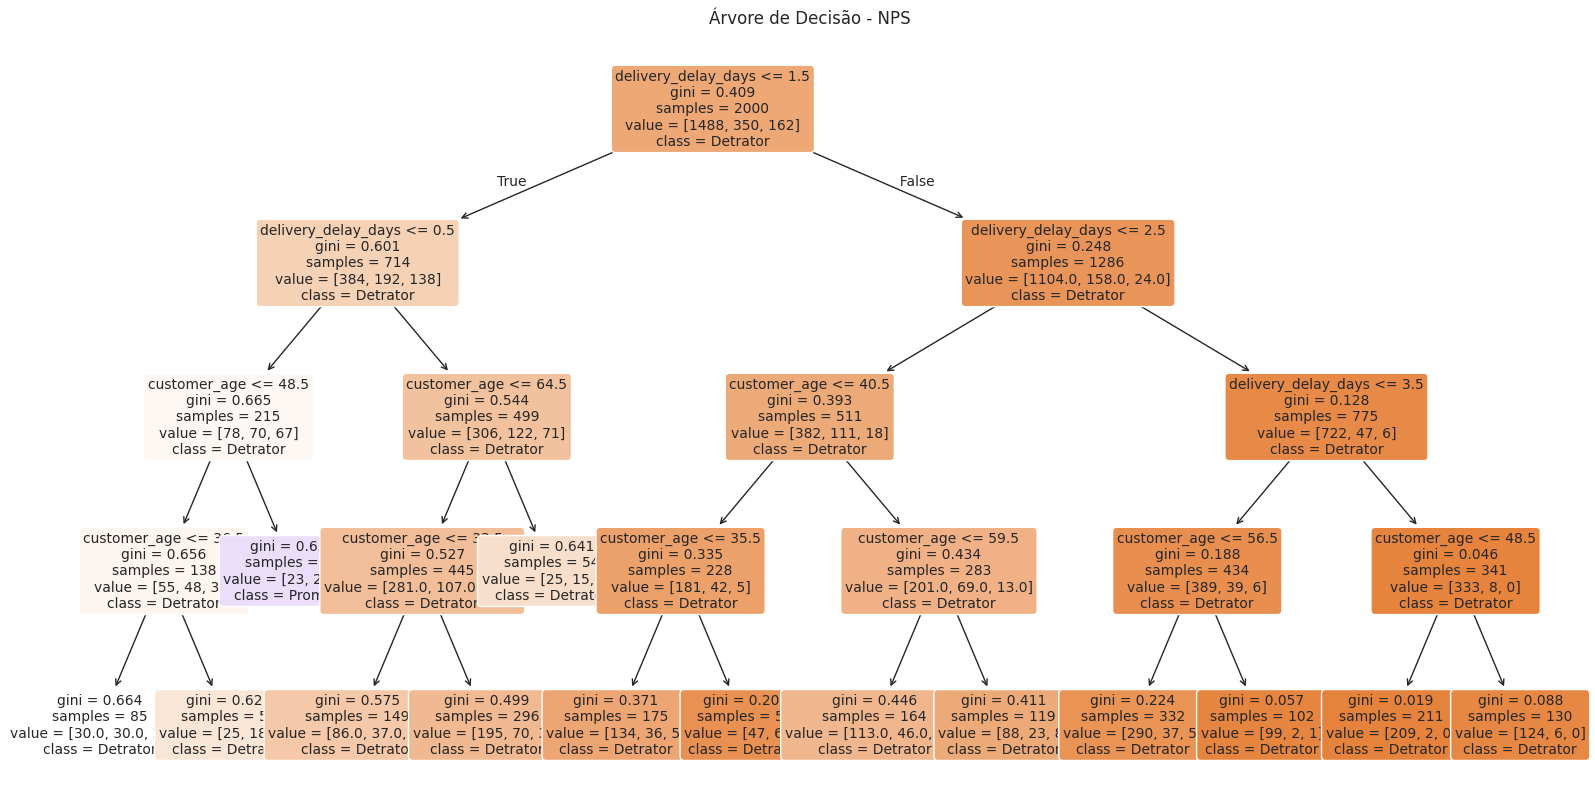

In [40]:
#Visualizar arvore de descisão
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Detrator", "Neutro", "Promotor"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão - NPS")
plt.show()


In [ ]:
#


In [ ]:
#tudo que é construido tem o seu atributo exemplo quais linhas colunas
notas.shape

(100836, 4)

In [ ]:
#alterando nomes das colunas ja que dentro de um conjunto há mais de um elemento ou seja []
notas.columns=["usuarioId", "filmeId", "nota", "momento"]
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
notas["nota"].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [ ]:
#contando valores dentro de um conjunto de dados de uma coluna
notas["nota"].value_counts()

KeyError: 'nota'

In [ ]:
#media desse conjunto de itens desse grupo de valores
notas["nota"].mean()

np.float64(3.501556983616962)

In [ ]:
pd.read_csv('/ratings.csv')

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
#usar metodos exemplo mediana para descobrir o meio de uma amostra
notas['nota'].median()


3.5

In [ ]:
mediana = notas["nota"].median()
media = notas["nota"].mean()
print(f"Mediana é {mediana}")
print(f"Média é {media}")

Mediana é 3.5
Média é 3.501556983616962


In [ ]:
#uma breve descriva do dataframe um descritivo
notas['nota'].describe()

,nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


<Axes: ylabel='nota'>

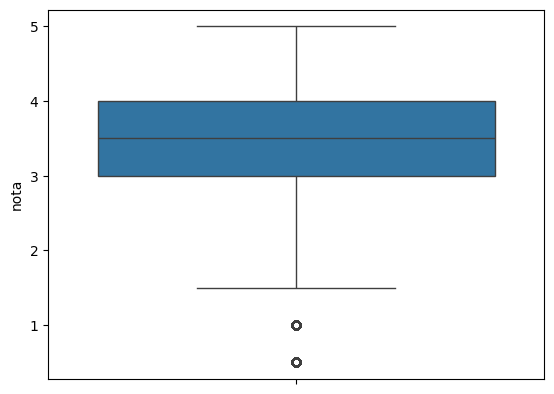

In [ ]:
#quero saber em forma de grafico aonde se concentra o publico no range de notas, usamos o
import seaborn as sns
sns.boxplot(notas["nota"])

In [ ]:
#atividade de entendimento
import pandas as pd

# Criando um DataFrame simples
dados = { 'Nome': ['Mirla', 'Ana', 'Daniel'],
   'Idade': [25, 30, 35],
              'Salario': [5000, 6000, 8000]}
df = pd.DataFrame(dados)
df

In [ ]:
#amostragem aleatória randomica
#amostragem estratifica seleciona alguns grupos respectivamente
#vies a base tem certo vicio
#tervalo de confiança=fixa da dsitribuição de seus dados, estimar certa confiança,media
#alguns requisitios para este intervalo de confiança(primeira a distruiblção dos dados)
#bootstrap reamostragem em cima de uma amostra que nao segue uma anormalidade assimetrica vdrificar outliers
#

In [ ]:
Teste t independente
t = -4.8475
p-value = 0.0000 < 0.05. Há evidência estatística para diferença significativa.
Teste t pareado
t = -20.1083
p-value = 0.0000 < 0.05. Há evidência estatística para diferença significativa.